In [ ]:
with open("Copper_rlzGain_frequency_phantom.txt", "r") as f:
    print(f.read())

#Parameters = {Conductivity=3000; L=38; Thickness=0.01; W=3; depth=15}
#"Frequency / GHz"	"Realized Gain,3D,Max. Value (Solid Angle) [Real]"
#--------------------------------------------------------------------
0.10000000000000	-50.311740485973
0.15000000000000	-42.139881427682
0.20000000000000	-35.854511216814
0.25000000000000	-30.488053585277
0.30000000000000	-27.703267068021
0.35000000000000	-28.295377871346
0.40000000000000	-27.738030601723
0.45000000000000	-24.867671363834
0.50000000000000	-24.318256011161
0.55000000000000	-26.219822048678
0.60000000000000	-27.067383439217
0.65000000000000	-25.243585807396
0.70000000000000	-22.927739454877
0.75000000000000	-21.341982727317
0.80000000000000	-20.599638973415
0.85000000000000	-20.324998344854
0.90000000000000	-20.296548138468
0.95000000000000	-19.927169871476
1.0000000000000	-20.138919511574
1.0500000000000	-20.631895203254
1.1000000000000	-21.602121461062
1.1500000000000	-22.204043201549
1.2000000000000	-22.899279041220
1.2500000000

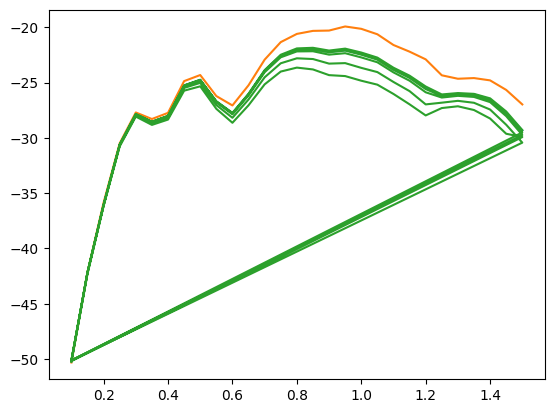

In [ ]:
# Single curves
plt.plot(x2, y2, label="PEDOT Phantom")
plt.plot(x3, y3, label="Updated Phantom")

# If x1 is NOT the 5-sweep version, include it:
plt.plot(x1, y1, label="Implant Dipole (900 MHz Meander)")

In [ ]:
import matplotlib.pyplot as plt

def load_data(filename):
    x = []
    y = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            # skip comments / headers
            if not line or line.startswith("#"):
                continue

            parts = line.split()

            x.append(float(parts[0]))
            y.append(float(parts[1]))

    return x, y

In [ ]:
import matplotlib.pyplot as plt

def load_multiple_datasets(filename):
    datasets = []
    x, y = [], []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            # skip comments
            if line.startswith("#") or not line:
                # if we already have data, save current block
                if x and y:
                    datasets.append((x, y))
                    x, y = [], []
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            x.append(float(parts[0]))
            y.append(float(parts[1]))

    # add last dataset
    if x and y:
        datasets.append((x, y))

    return datasets

In [ ]:
data_sets = load_multiple_datasets(
    "pedot_implant_dipole_900MHz_meander_updatedPhantomrlzGain_parasweep.txt"
)

print("Number of datasets:", len(data_sets))

Number of datasets: 5


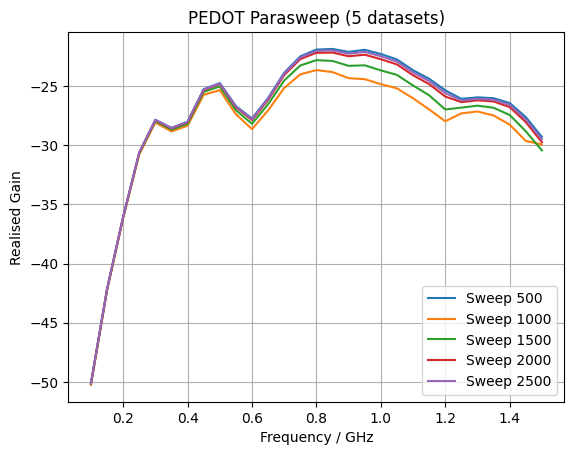

In [ ]:
for i, (x, y) in enumerate(data_sets):
    plt.plot(x, y, label=f"Sweep {(i+1)*500}")

plt.xlabel("Frequency / GHz")
plt.ylabel("Realised Gain")
plt.title("PEDOT Parasweep (5 datasets)")

plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

conductivities = [500, 1000, 2000, 2500, 3000]

In [ ]:
def load_multiple_datasets(filename):
    datasets = []
    x, y = [], []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("#") or not line:
                if x and y:
                    datasets.append((x, y))
                    x, y = [], []
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            x.append(float(parts[0]))
            y.append(float(parts[1]))

    if x and y:
        datasets.append((x, y))

    return datasets

In [ ]:
data_sets = load_multiple_datasets(
    "pedot_implant_dipole_900MHz_meander_updatedPhantomrlzGain_parasweep_rearrange.txt"
)

print(len(data_sets))  # should be 5

5


In [ ]:
x1, y1 = load_data("pedot_implant_dipole_900MHz_meander_updatedPhantomrlzGain_parasweep_rearrange.txt")
#x2, y2 = load_data("pedot_rlzGain_frequency_phantom.txt")
x3, y3 = load_data("CopperUpdatedPhantom_rlzGain.txt")

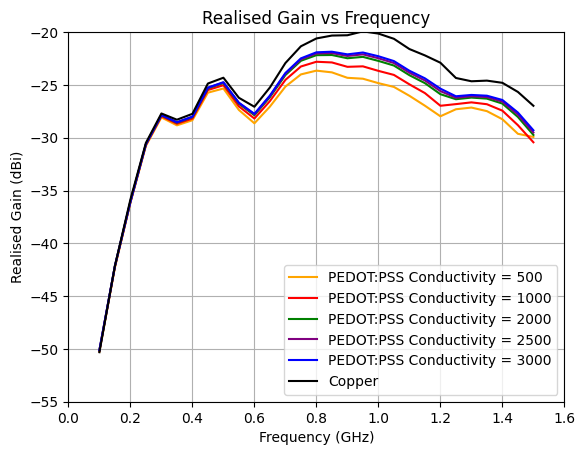

In [ ]:
#plt.figure(figsize=(10, 6))

colors = ["orange", "red", "green","purple", "blue"]
for i, (x, y) in enumerate(data_sets):
    label = f"PEDOT:PSS Conductivity = {conductivities[i]}"
    plt.plot(x, y, color=colors[i], label=label)

plt.plot(x3, y3, label="Copper", color='black')

plt.xlabel("Frequency (GHz)")
plt.ylabel("Realised Gain (dBi)")
plt.title("Realised Gain vs Frequency")


plt.ylim(-55, -20)
plt.xlim(0, 1.6)

plt.grid(True)
plt.legend()
plt.show()


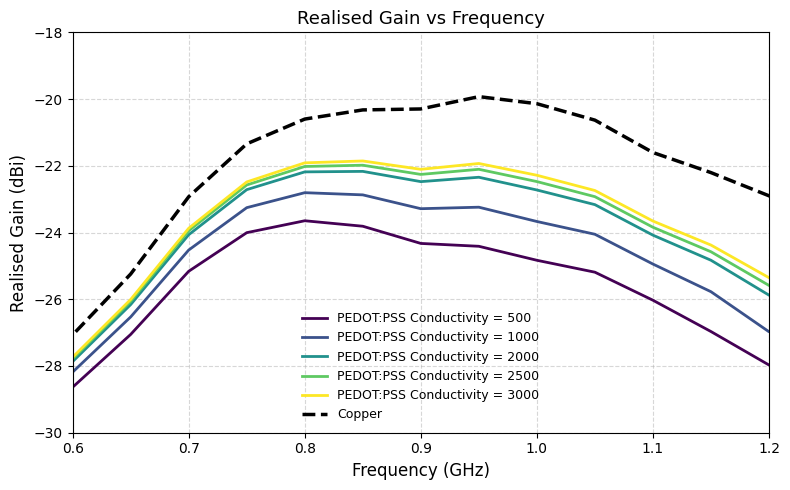

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure
plt.figure(figsize=(8, 5))

# Color map for conductivity
colors = plt.cm.viridis(np.linspace(0, 1, len(data_sets)))

# Plot conductivity sweeps
for i, (x, y) in enumerate(data_sets):
    plt.plot(
        x, y,
        color=colors[i],
        linewidth=2,
        label=f"PEDOT:PSS Conductivity = {conductivities[i]}"
    )

# Copper curve (highlighted)
plt.plot(
    x3, y3,
    color="black",
    linewidth=2.5,
    linestyle="--",
    label="Copper"
)

# Labels
plt.xlabel("Frequency (GHz)", fontsize=12)
plt.ylabel("Realised Gain (dBi)", fontsize=12)
plt.title("Realised Gain vs Frequency", fontsize=13)

# Axis limits
plt.xlim(0.6, 1.2)
plt.ylim(-30, -18)

# Grid (subtle)
plt.grid(True, linestyle='--', alpha=0.5)

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Legend (clean placement)
plt.legend(fontsize=9, loc='best', frameon=False)

# Tight layout (important)
plt.tight_layout()

# Save high-quality outputs
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.savefig("plot.pdf", bbox_inches='tight')  # best for reports

plt.show()